In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split


In [75]:
titanic=sns.load_dataset("titanic")

In [76]:
titanic.head()
titanic.describe()
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [77]:
features=["pclass","sex","fare","embarked","age"]
target=["survived"]

In [78]:
#missing data
from sklearn.impute import SimpleImputer
imp_median=SimpleImputer(strategy="median")
titanic[["age"]]=imp_median.fit_transform(titanic[["age"]])

imp_freq=SimpleImputer(strategy="most_frequent")
titanic[["embarked"]]=imp_freq.fit_transform(titanic[["embarked"]])

In [79]:
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [80]:
#encoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

titanic["sex"]=le.fit_transform(titanic["sex"])
titanic["embarked"]=le.fit_transform(titanic["embarked"])

In [81]:
X=titanic[features]
y=titanic[target]

In [82]:
X.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [83]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [84]:
#Decision Tree Model-No Pruning
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier()

model.fit(X_train,y_train)


DecisionTreeClassifier()

In [85]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(X_test)

print("Accuracy Score:",accuracy_score(y_test,y_pred))

Accuracy Score: 0.7653631284916201


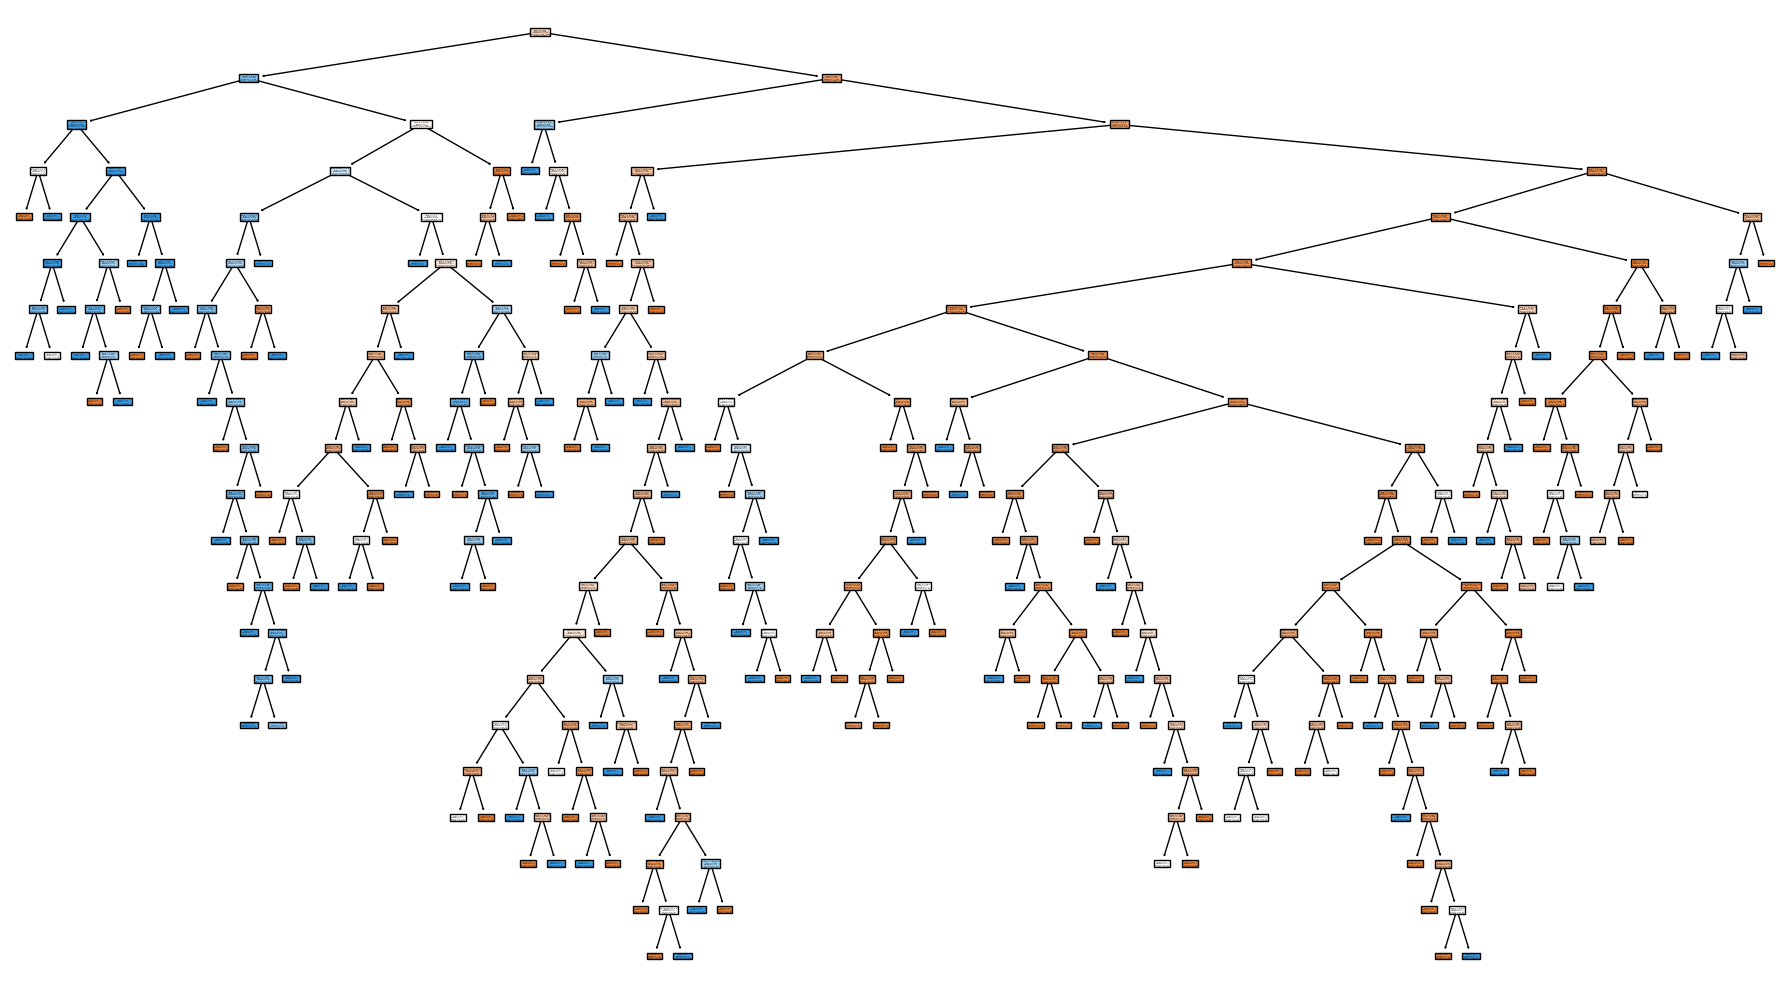

In [86]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)

plt.tight_layout()
plt.show()

for sample split=10,accuracy=0.7988826815642458
for sample split=15,accuracy=0.7988826815642458
for sample split=20,accuracy=0.7988826815642458
for sample split=25,accuracy=0.7932960893854749
for sample split=30,accuracy=0.7932960893854749


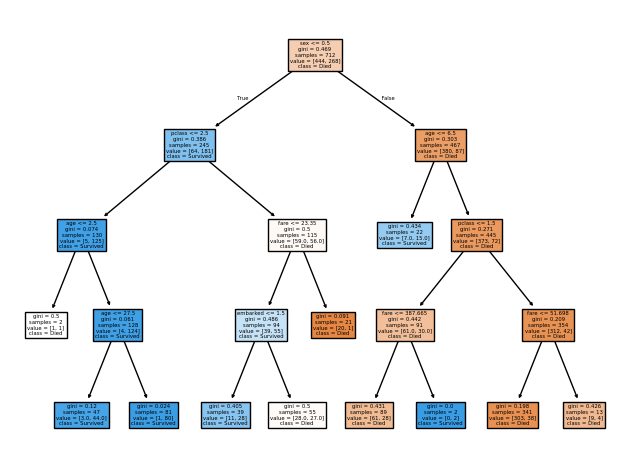

In [87]:
#Decision Tree with PrePruning
# max_depth=[2,3,4,5,6,7,8,9,10]
min_sample_splits=[10,15,20,25,30]
for split in min_sample_splits:
    model=DecisionTreeClassifier(max_depth=4,min_samples_split=split)
    model.fit(X_train,y_train)

    acc=model.score(X_test,y_test)
    print(f"for sample split={split},accuracy={acc}")


    if(depth==4):
        plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)

plt.tight_layout()
plt.show()
        

    



In [88]:
#DecisionTree with Post Pruning
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [89]:
path=full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas=path.ccp_alphas

print(ccp_alphas)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [90]:
#Train our model for all alphas
trees=[]

for alpha in ccp_alphas:
    model=DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(X_train,y_train)
    

    trees.append((model,alpha))

In [91]:
best_acc=0
best_alpha=0

for model,alpha in trees:
    curr_acc=model.score(X_test,y_test)

    if curr_acc>best_acc:
        best_acc=curr_acc;
        best_alpha=alpha    

In [92]:
best_acc

0.8379888268156425

In [93]:
best_alpha

0.0015407231242023183

In [94]:
best_model=DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)

DecisionTreeClassifier(ccp_alpha=0.0015407231242023183)

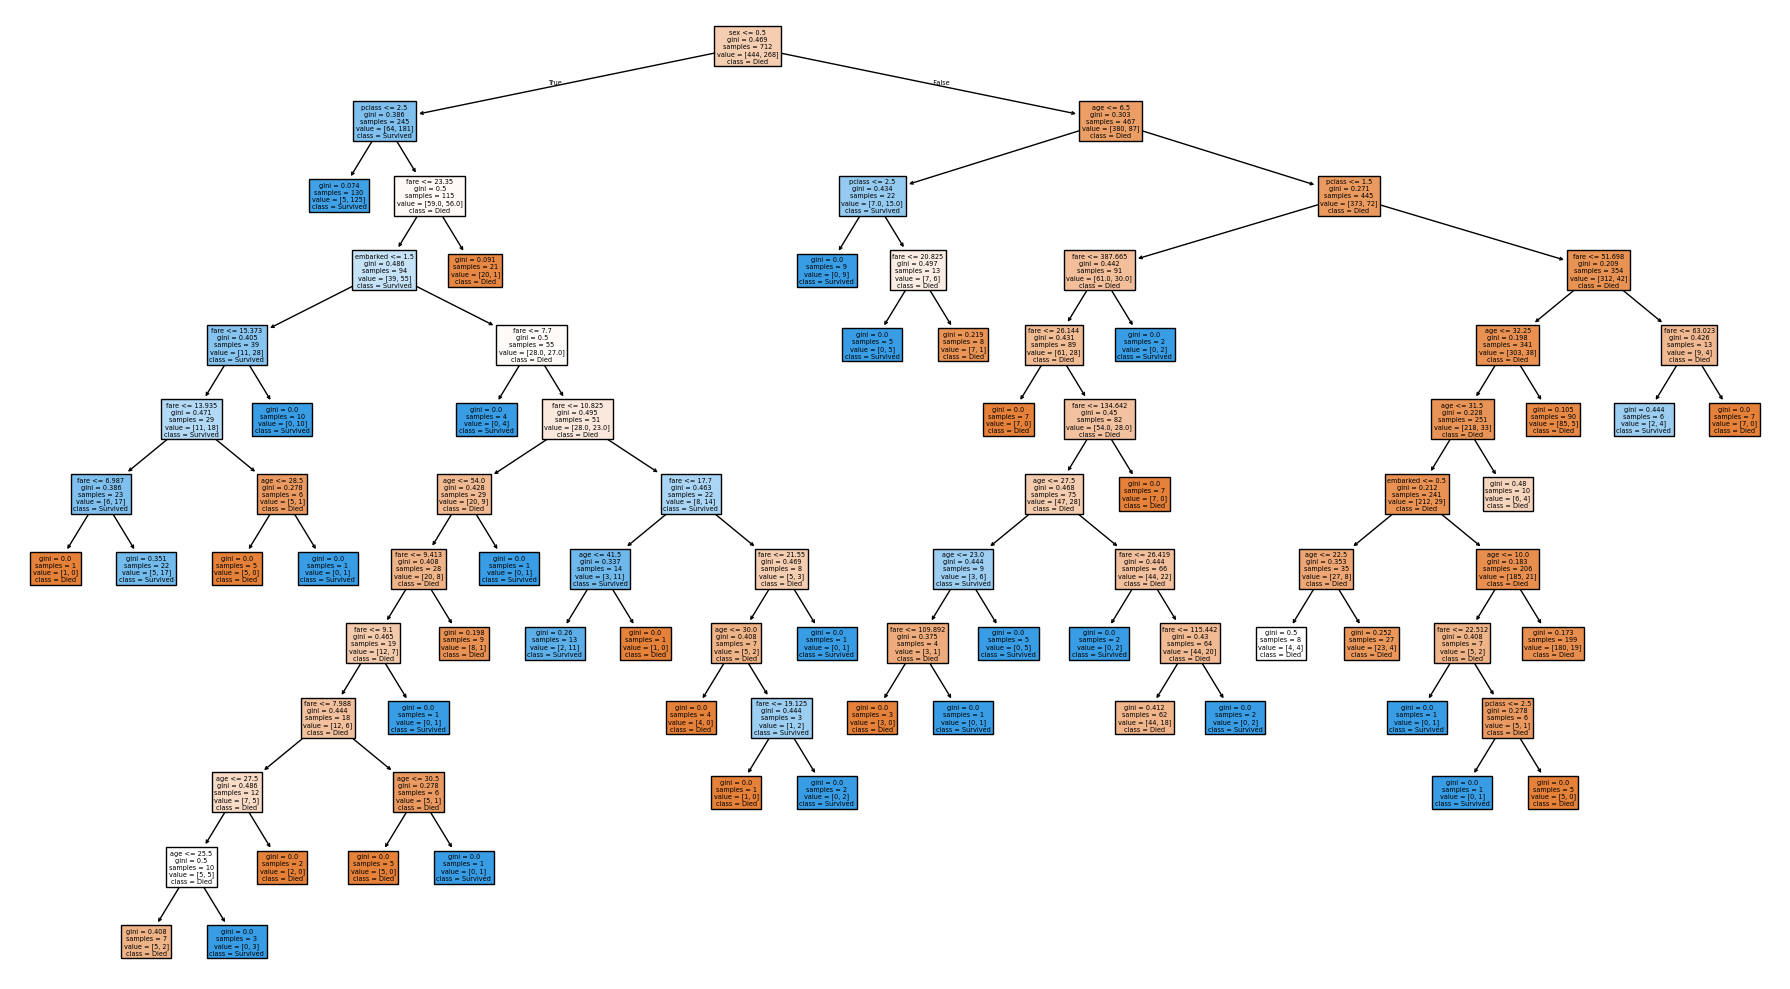

In [95]:
plt.figure(figsize=(18,10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)

plt.tight_layout()
plt.show()

In [119]:
print(best_model.score(X_test,y_test))

0.8324022346368715
